In [285]:
library(data.table)
library(irlba)
library(tidyr)
library(purrr)
library(ggplot2)
library(scuttle)
library(ggpubr)
library(patchwork)

In [2]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/03_Stat3_RNA/azami_et_al"

In [288]:
options(repr.plot.width=10, repr.plot.height=8)

In [529]:
head(meta)

,sample,stage,genotype,cluster
,<chr>,<chr>,<fct>,<int>
E5.5_Stat3null_1,E5.5_Stat3null_1,E5.5,Stat3-/-,1
E5.5_Stat3null_2,E5.5_Stat3null_2,E5.5,Stat3-/-,1
E5.5_Stat3null_3,E5.5_Stat3null_3,E5.5,Stat3-/-,1
E5.5_Stat3null_4,E5.5_Stat3null_4,E5.5,Stat3-/-,1
E5.5_WT_1,E5.5_WT_1,E5.5,WT,1
E5.5_WT_2,E5.5_WT_2,E5.5,WT,1


In [530]:
# Load metadata, remove Extra embryonic
excl = c("E5.5_Stat3null_1", "E6.5_Stat3null_1", "E6.5_Stat3null_2", "E6.5_WT_1", "E6.5_WT_2", "E6.5_WT_3", "E6.5_WT_4", "E7.5_WT_3") 
# Make sure these samples are excluded for the right reasons!!!
meta = fread('phenodata_epi2.csv') %>% .[!grep('ex', sample)] %>% .[!sample %in% excl,]

# Load count data
counts = fread('gene_count_matrix_epiblast.csv') %>% 
    .[,gene_id:=strsplit(gene_id, '[|]') %>% map(2)] %>% # get gene names
    .[,gene_id:=make.names(gene_id, unique=TRUE)] %>% # make gene names unique
    as.data.frame() %>% tibble::column_to_rownames('gene_id') %>% # set gene names as rownames
    .[,meta$sample] %>% # remove ExE  %>% 
    .[rowSums(.)>10,] # remove lowly expressed genes

genes = rownames(counts)
head(counts)
head(meta)

,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Xkr4,5,11,6,4,48,0,96,94,76,142,⋯,215,235,232,134,170,315,138,178,166,180
Gm18956,4,0,0,0,0,0,0,0,0,0,⋯,3,2,3,0,0,0,4,5,0,0
Gm37686,0,0,0,0,0,0,4,0,0,0,⋯,18,0,27,4,3,10,11,0,0,3
Gm37329,5,11,20,0,0,0,0,4,13,22,⋯,48,10,9,13,9,0,23,8,18,0
Gm38148,19,23,11,0,7,0,33,57,43,53,⋯,80,6,50,47,25,43,8,36,63,91
Gm37180,3,0,91,0,13,0,5,26,7,34,⋯,26,28,40,47,110,39,15,11,25,10


sample,stage,genotype,cluster
<chr>,<chr>,<chr>,<int>
E5.5_Stat3null_2,E5.5,Stat3-/-,1
E5.5_Stat3null_3,E5.5,Stat3-/-,1
E5.5_Stat3null_4,E5.5,Stat3-/-,1
E5.5_WT_1,E5.5,WT,1
E5.5_WT_2,E5.5,WT,1
E6.5_Stat3null_3,E6.5,Stat3-/-,2


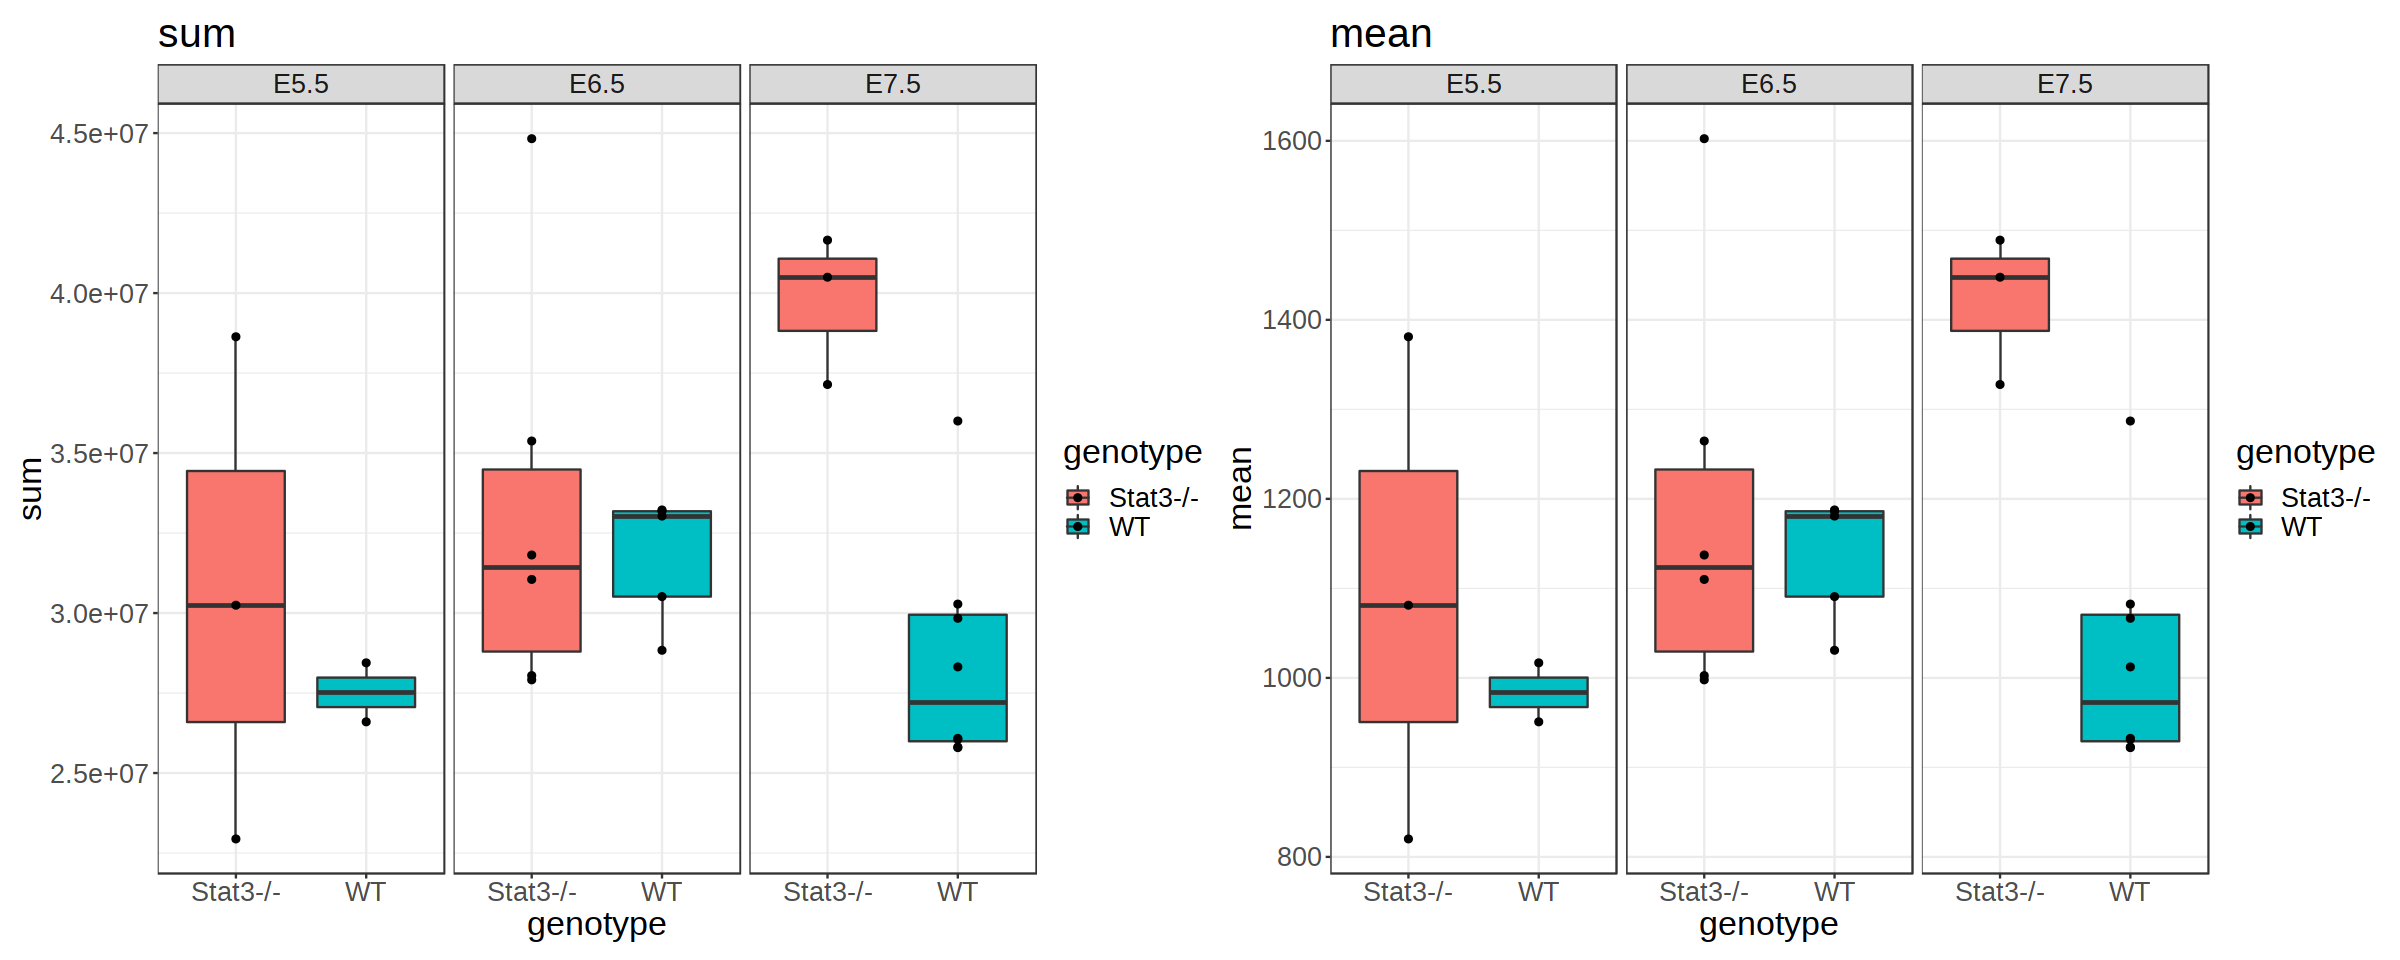

In [531]:
# sample statistics
sample = data.table(sample=colnames(counts), 
                   sum = colSums(counts), 
                   mean = colMeans(counts))
meta_sample = merge(meta, sample, by='sample')

plot_stat = function(x){
    ggplot(meta_sample, aes_string('genotype', x, fill='genotype')) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_point() + 
        viridis::scale_color_viridis() + 
        facet_wrap(~stage) + 
        ggtitle(x) +
        theme_bw() + theme(text=element_text(size=20))
    }
options(repr.plot.width=20, repr.plot.height=8)
plot_stat('sum') +  plot_stat('mean')
options(repr.plot.width=10, repr.plot.height=8)

In [532]:
# log normalisation
logcounts = lapply(1:nrow(meta), function(x){
    tmp = counts[,x]
    tmp = log1p(tmp/sum(tmp) * 10000)
    }) %>% do.call('cbind', .) #%>% as.data.table(.) %>% setnames(meta$sample)
rownames(logcounts) = rownames(counts)
colnames(logcounts) = colnames(counts)
head(logcounts)

,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_3,E6.5_Stat3null_4,E6.5_Stat3null_5,E6.5_Stat3null_6,E6.5_Stat3null_7,⋯,E7.5_Stat3null_2,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,0.002177156,0.003630366,0.001551808,0.00150261,0.016734389,0,0.030448869,0.029118168,0.021255617,0.049621340,⋯,0.0562718990,0.0548823634,0.078747379,0.050646532,0.063212562,0.10036575,0.037615055,0.066680870,0.053371108,0.066729911
Gm18956,0.001742104,0.000000000,0.000000000,0.00000000,0.000000000,0,0.000000000,0.000000000,0.000000000,0.000000000,⋯,0.0008073756,0.0004800238,0.001058891,0.000000000,0.000000000,0.00000000,0.001110440,0.001935045,0.000000000,0.000000000
Gm37686,0.000000000,0.000000000,0.000000000,0.00000000,0.000000000,0,0.001287387,0.000000000,0.000000000,0.000000000,⋯,0.0048345046,0.0000000000,0.009489898,0.001549575,0.001150865,0.00334599,0.003050748,0.000000000,0.000000000,0.001149451
Gm37329,0.002177156,0.003630366,0.005163356,0.00000000,0.000000000,0,0.000000000,0.001256497,0.003668010,0.007850849,⋯,0.0128404335,0.0023978180,0.003173316,0.005027364,0.003448630,0.00000000,0.006368255,0.003094277,0.005926850,0.000000000
Gm38148,0.008248095,0.007575791,0.002843144,0.00000000,0.002457942,0,0.010571702,0.017757735,0.012081649,0.018809827,⋯,0.0213100296,0.0014393806,0.017503453,0.018057594,0.009550316,0.01430899,0.002219648,0.013849463,0.020592090,0.034291978
Gm37180,0.001306862,0.000000000,0.023280911,0.00000000,0.004559952,0,0.001608975,0.008139153,0.001976754,0.012107292,⋯,0.0069756939,0.0066994546,0.014027187,0.018057594,0.041355634,0.01298653,0.004157807,0.004252167,0.008222283,0.003826376


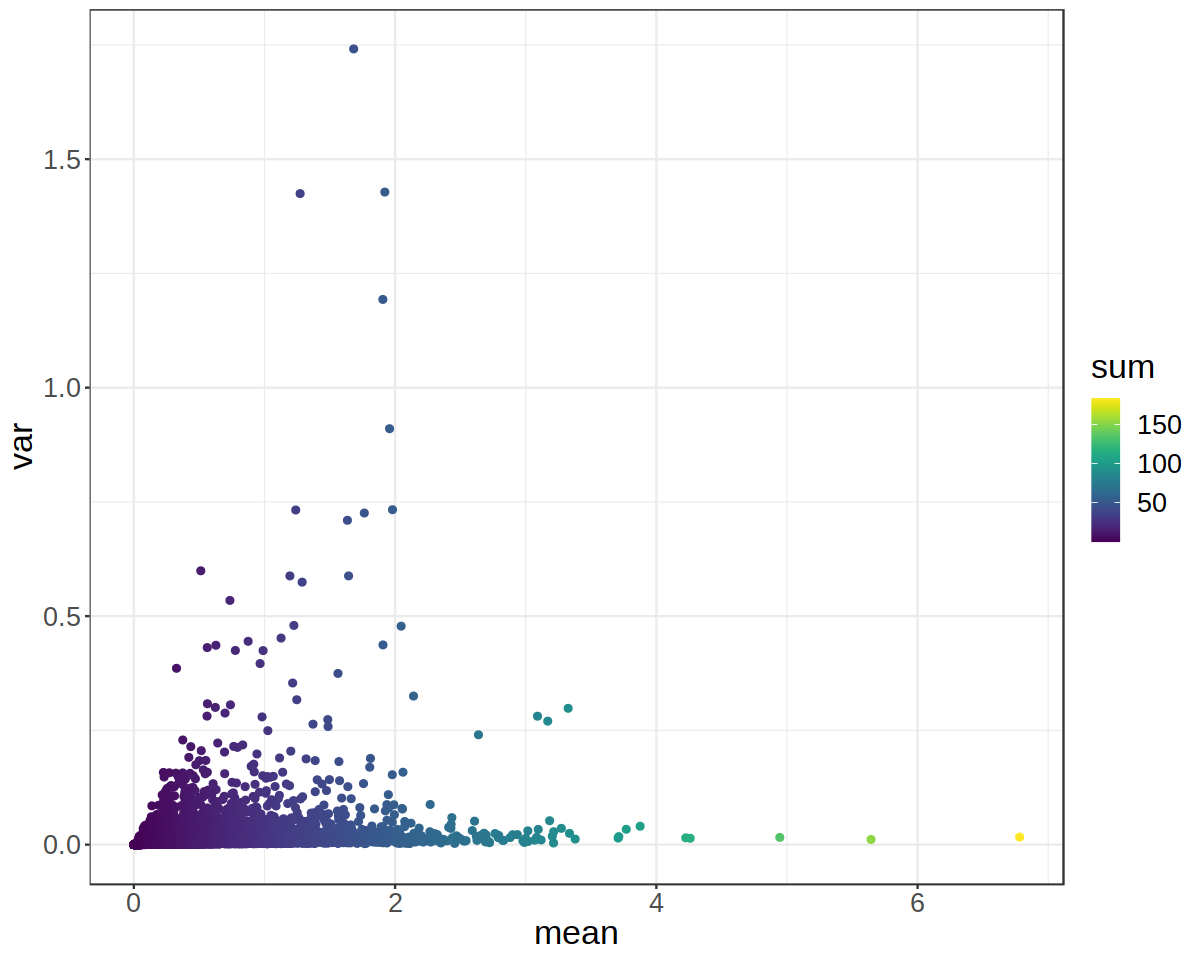

In [533]:
# Gene statistics
genes = data.table(gene=rownames(logcounts), 
                   sum = rowSums(logcounts), 
                   mean = rowMeans(logcounts), 
                   var = rowVars(logcounts))

ggplot(genes, aes(mean, var, col=sum)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw() + theme(text=element_text(size=20))

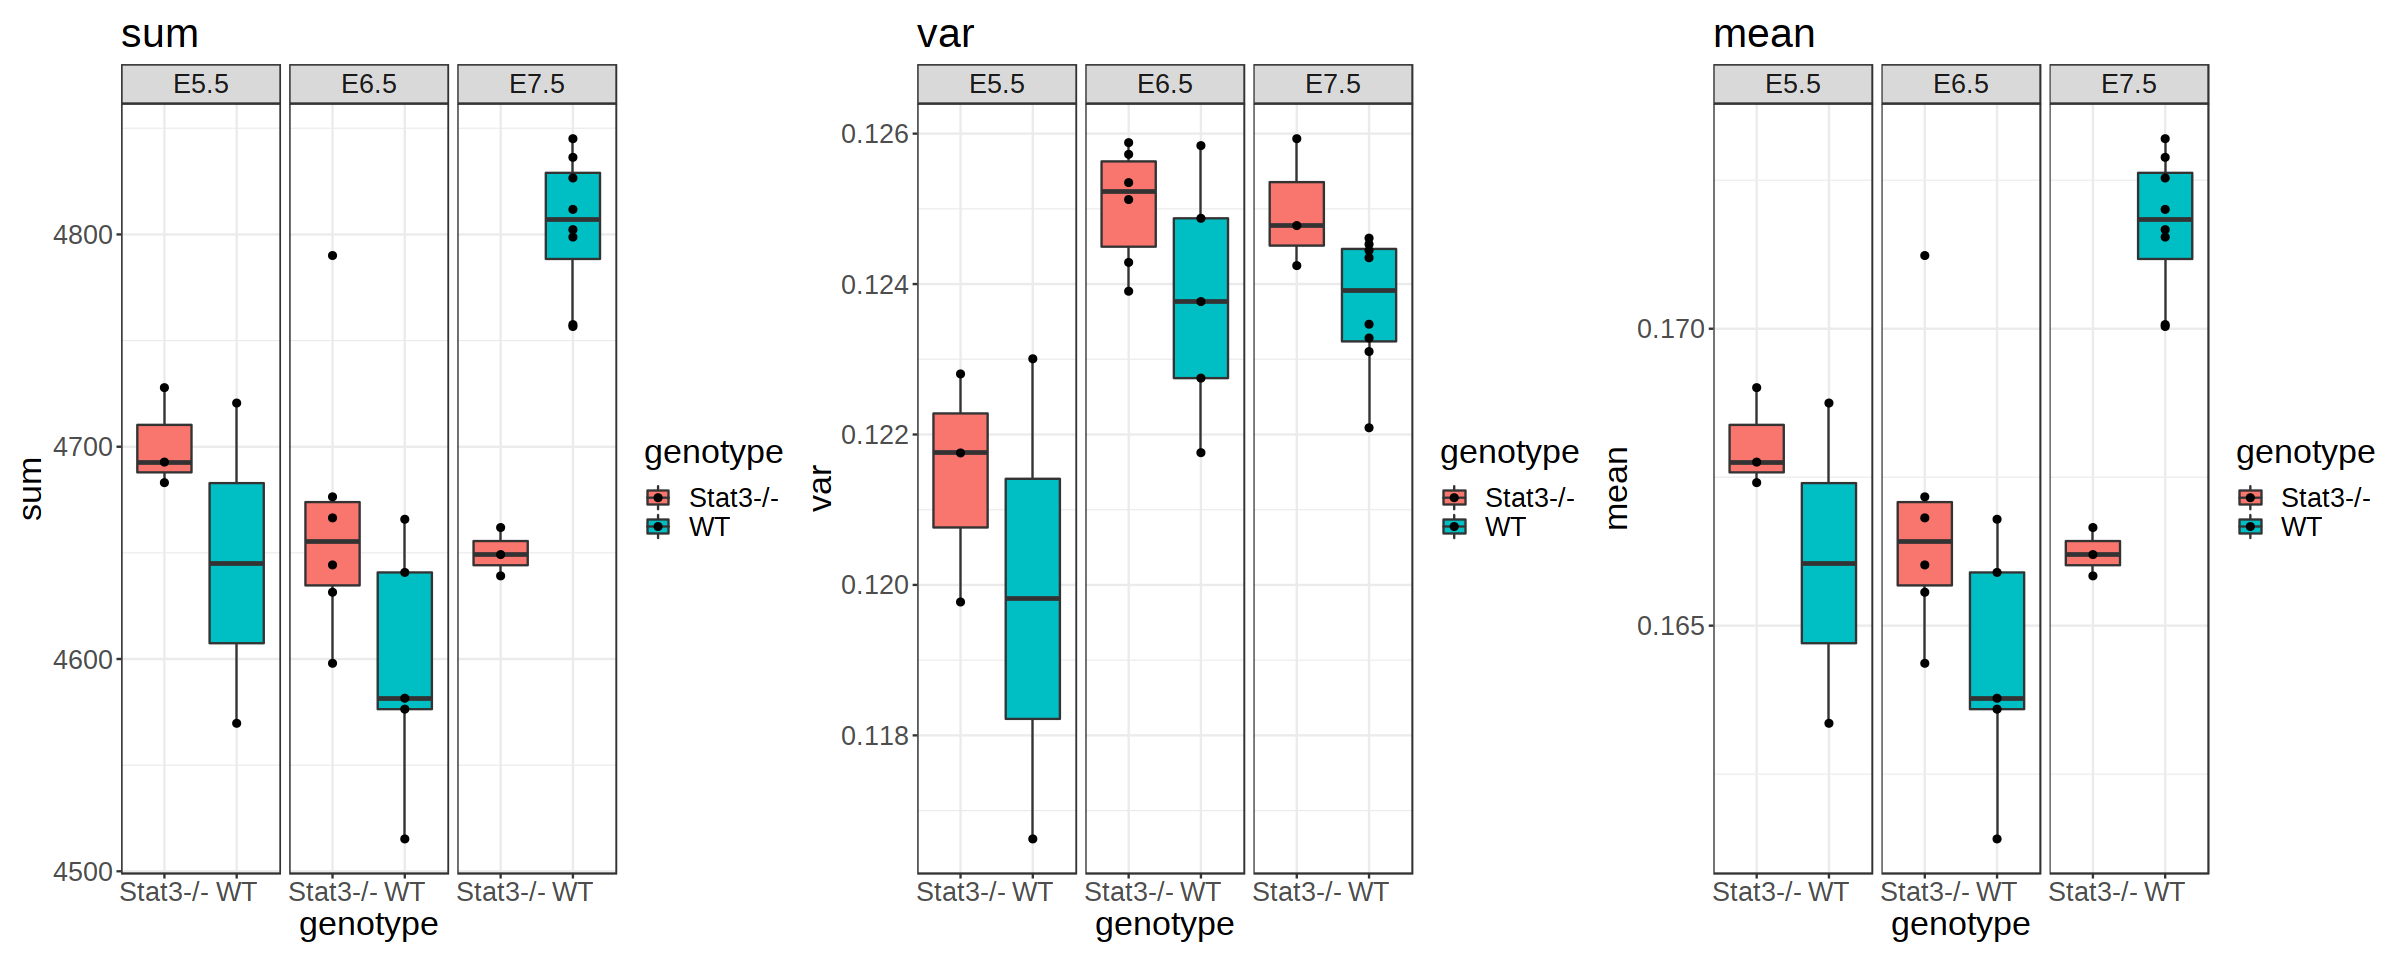

In [534]:
# sample statistics
sample = data.table(sample=colnames(logcounts), 
                   sum = colSums(logcounts), 
                   mean = colMeans(logcounts), 
                   var = colVars(logcounts))
meta_sample = merge(meta, sample, by='sample')

plot_stat = function(x){
    ggplot(meta_sample, aes_string('genotype', x, fill='genotype')) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_point() + 
        viridis::scale_color_viridis() + 
        facet_wrap(~stage) + 
        ggtitle(x) +
        theme_bw() + theme(text=element_text(size=20))
    }
options(repr.plot.width=20, repr.plot.height=8)
plot_stat('sum') + plot_stat('var') + plot_stat('mean')
options(repr.plot.width=10, repr.plot.height=8)

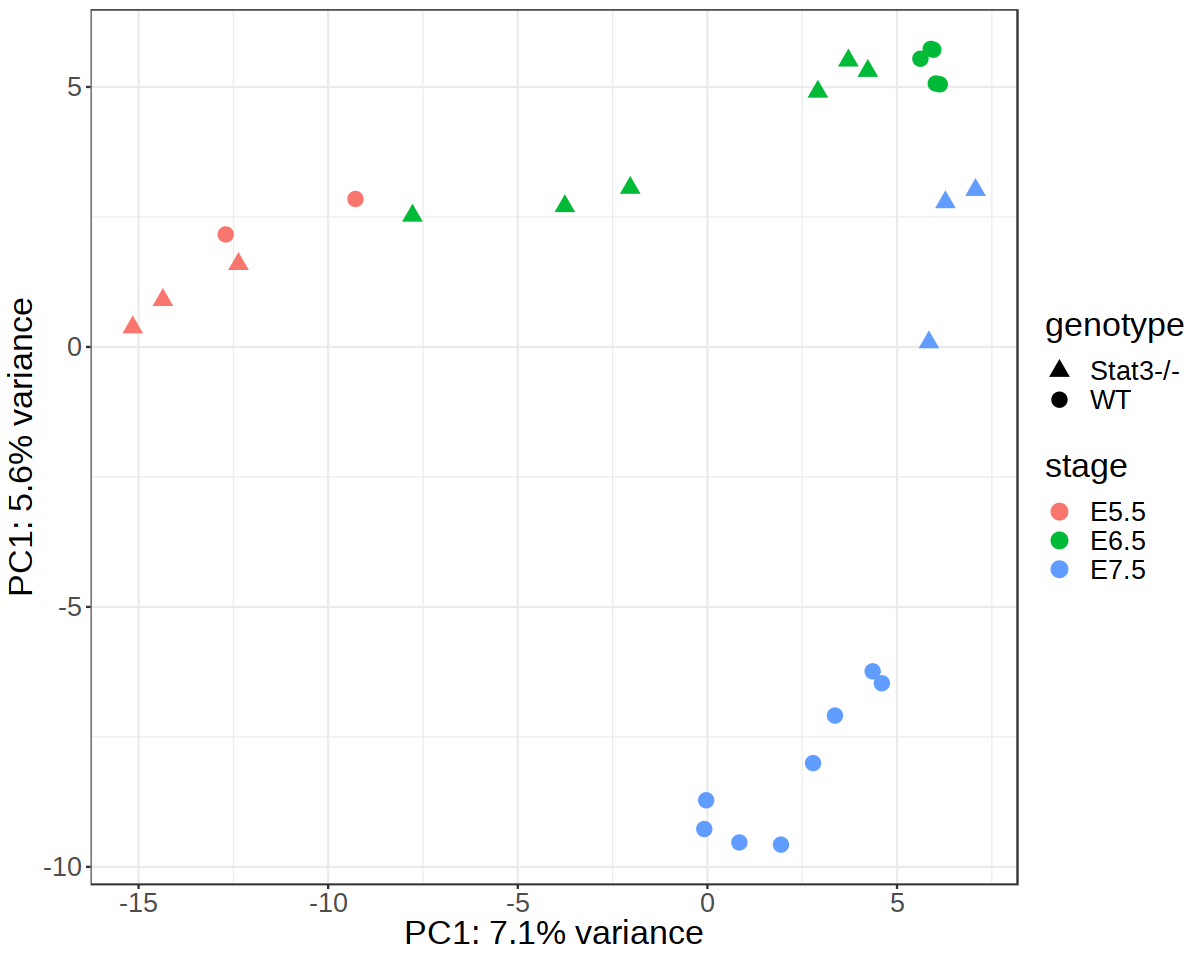

In [555]:
# Select variable genes
var_genes = genes[order(-var), gene] %>% head(10000)
logcounts_var = logcounts[var_genes,]

# PCA 
pca = prcomp(t(as.matrix(logcounts_var)), scale=TRUE) # Does scale need to be TRUE?
meta_pca = cbind(meta_sample, pca$x)

# Plot
ggplot(meta_pca, aes(PC1, PC2, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3-/-'=17, 'WT'=16))+
    geom_point(size=4) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC1: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))

In [558]:
logcounts_cor = dist(logcounts_var)

In [559]:
logcounts_cor <- cor(logcounts_var)
colors <- colorRampPalette(c("blue","white","red"))(99)
annocolors <- list(
  genotype = c("WT"="#00afbb", "Stat3-/-"="#fc4e07"),
  stage = c("E5.5"="#66cc33", "E6.5"="#cc9933", "E7.5"="#3399cc")
)
meta$genotype <- factor(meta$genotype, levels = c("WT", "Stat3-/-"))
meta = as.data.frame(meta)
rownames(meta) = meta$sample 

In [536]:
gene_pca = pca$rotation
rownames(gene_pca) = var_genes

In [537]:
PC1 = as.data.table(gene_pca, keep.rownames=T)[,PC1:=abs(PC1)] %>% .[order(-PC1)] %>% head(20) %>% .$rn
PC2 = as.data.table(gene_pca, keep.rownames=T)[,PC2:=abs(PC2)] %>% .[order(-PC2)] %>% head(20) %>% .$rn
label = unique(c(PC1, PC2))

Warning message:
“ggrepel: 2 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


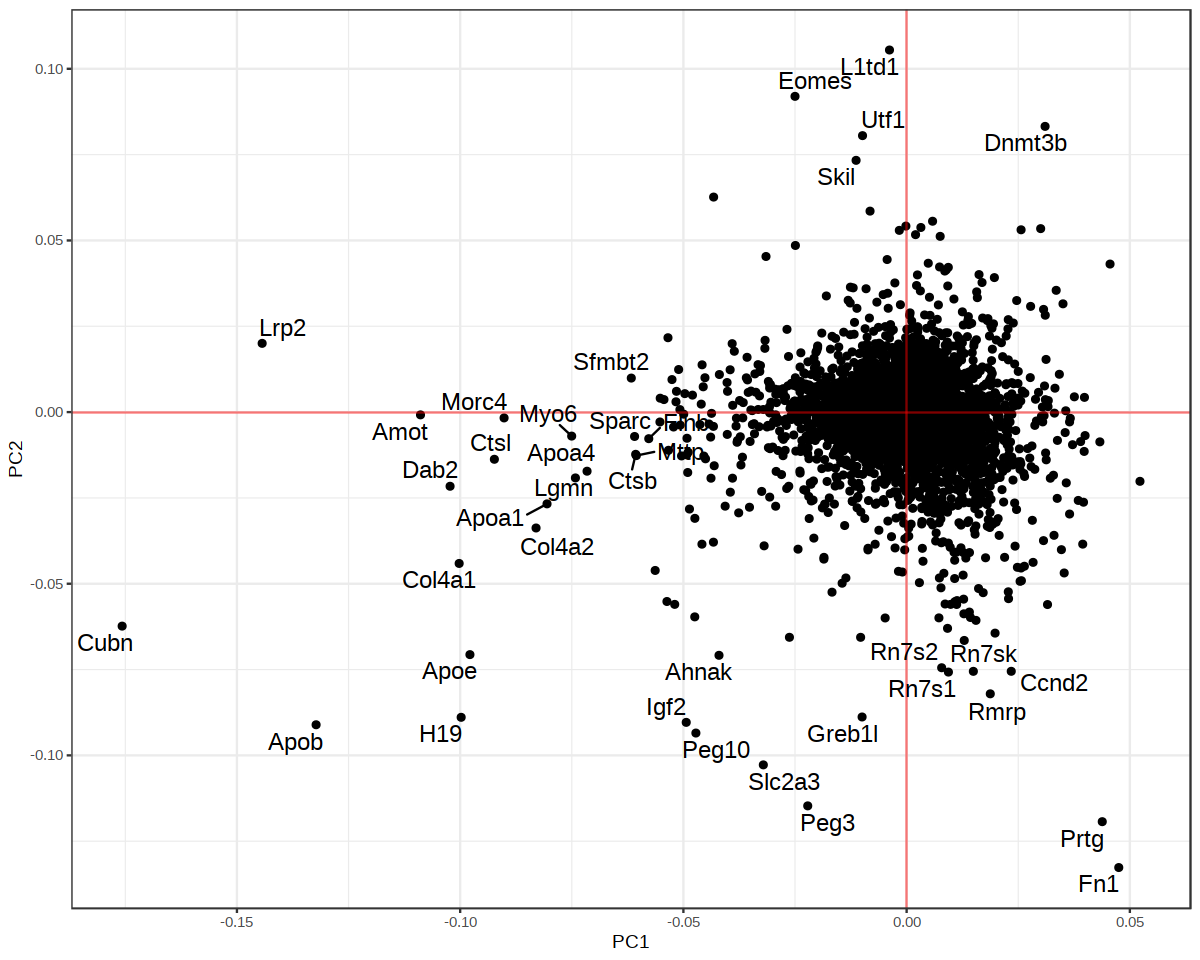

In [538]:
ggplot(as.data.frame(gene_pca), aes(PC1, PC2, label=rownames(gene_pca))) + 
    geom_point() +
    geom_hline(yintercept=0, color='red', alpha=0.5) + geom_vline(xintercept=0, color='red', alpha=0.5)+
    ggrepel::geom_text_repel(data = as.data.frame(gene_pca)[label,], 
             aes(label = label),
             color = "black", size=5) +
    theme_bw() 


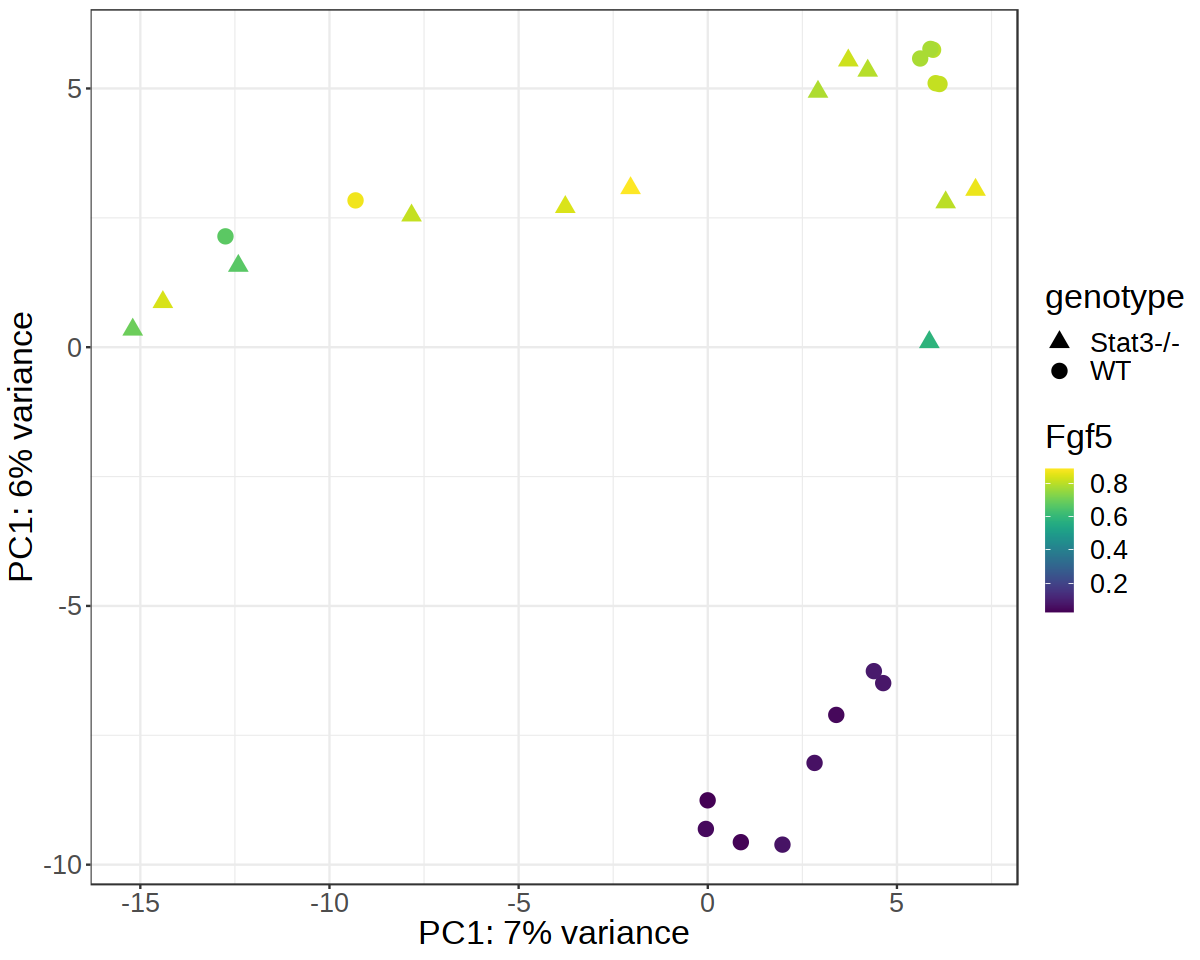

In [539]:
gene = 'Fgf5'
ggplot(meta_pca, aes(PC1, PC2, col=logcounts[gene,], shape=genotype)) + 
    scale_shape_manual(values=c('Stat3-/-'=17, 'WT'=16))+
    viridis::scale_color_viridis(name=gene) + 
    geom_point(size=4) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],0), '% variance'),
         y =  paste0('PC1: ', round(pca$sdev[2],0), '% variance')) + 
    theme(text=element_text(size=20, color='black'))

In [ ]:
genes_pca = cbind(var_genes, pca$rotation)

In [464]:
library(DESeq2)


In [475]:
test = vst(as.matrix(counts))

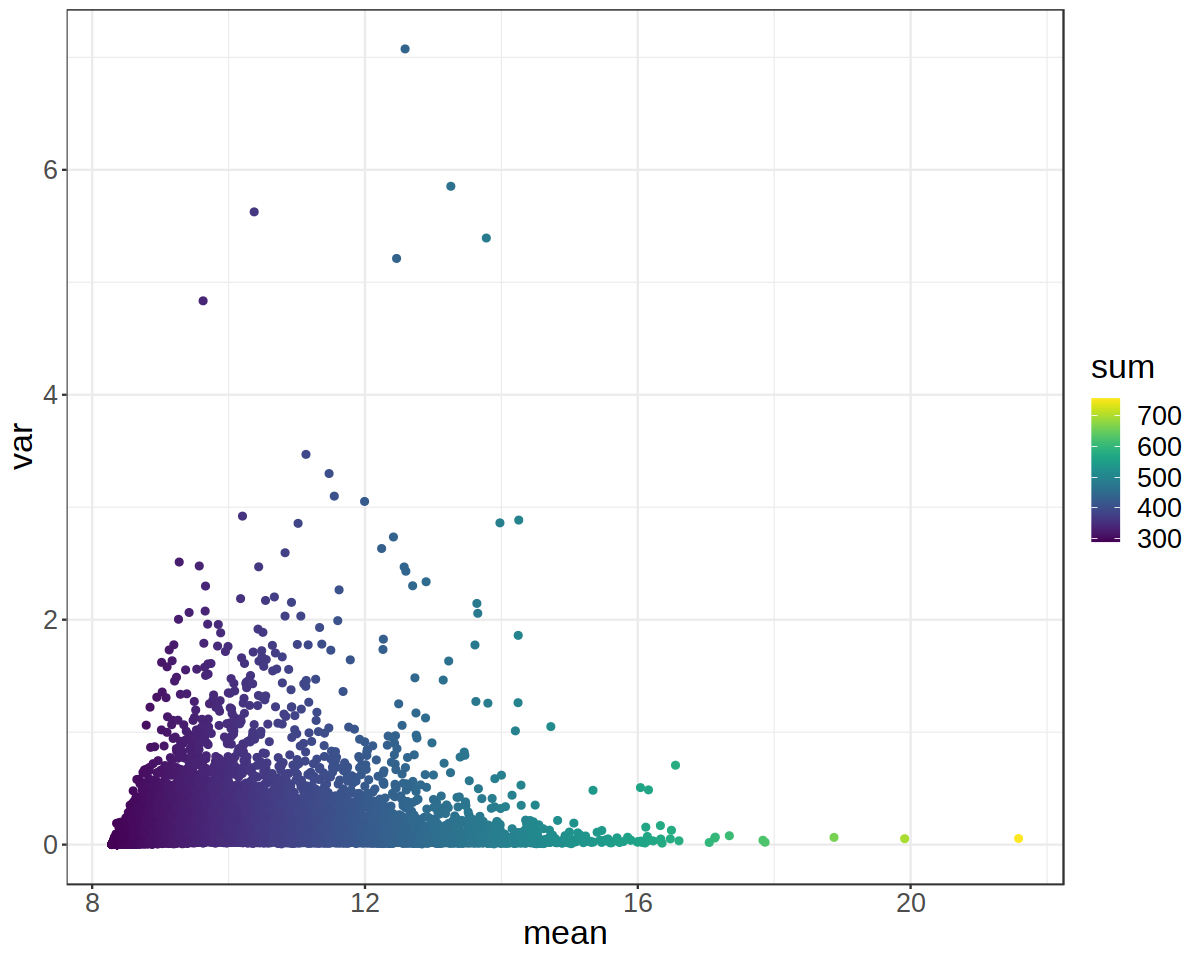

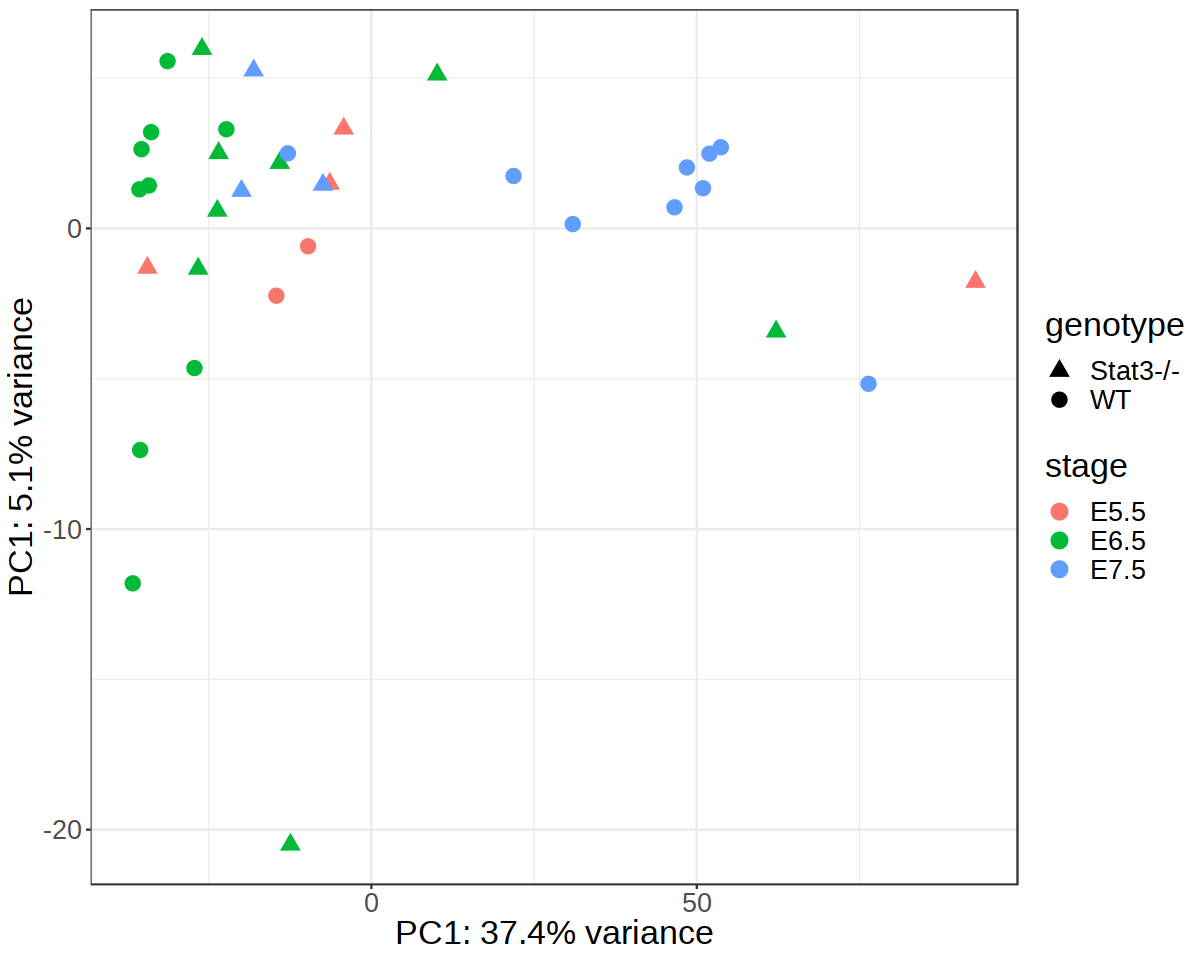

In [476]:
# Gene statistics
genes = data.table(gene=rownames(test), 
                   sum = rowSums(test), 
                   mean = rowMeans(test), 
                   var = rowVars(test))

ggplot(genes, aes(mean, var, col=sum)) + 
    geom_point() + 
    viridis::scale_color_viridis() + 
    theme_bw() + theme(text=element_text(size=20))
# Select variable genes
var_genes = genes[order(-var), gene] %>% head(5000)
logcounts_var = logcounts[test,]

# PCA 
pca = prcomp(t(as.matrix(logcounts_var)), scale=FALSE) #prcomp
meta_pca = cbind(meta_sample, pca$x)

# Plot
ggplot(meta_pca, aes(PC1, PC2, col=stage, shape=genotype)) + 
    scale_shape_manual(values=c('Stat3-/-'=17, 'WT'=16))+
    geom_point(size=4) +
    theme_bw() + 
    labs(x = paste0('PC1: ', round(pca$sdev[1],1), '% variance'),
         y =  paste0('PC1: ', round(pca$sdev[2],1), '% variance')) + 
    theme(text=element_text(size=20, color='black'))

In [477]:
dds = DESeqDataSetFromMatrix(countData = counts, colData = meta, design = ~ genotype + stage + genotype:stage)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [479]:
dds <- estimateSizeFactors(dds)

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



In [481]:
normalized_counts <- counts(dds, normalized=TRUE)

In [482]:
head(normalized_counts)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,21.48376,7.610061,13.04559,5.493831,5.441259,58.056119,29.13428,171.25031,0,101.750509,⋯,193.987786,275.441525,174.083462,132.058902,218.93902,350.20531,128.176233,229.995980,179.87130,224.240437
Gm18956,0.00000,6.088049,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0,0.000000,⋯,1.650960,3.561744,0.000000,7.819277,0.00000,0.00000,3.715253,6.460561,0.00000,0.000000
Gm37686,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000,0,4.239605,⋯,0.000000,32.055695,5.196521,6.081660,3.86363,11.11763,10.216946,0.000000,0.00000,3.737341
Gm37329,0.00000,7.610061,13.04559,18.312769,0.000000,0.000000,0.00000,0.00000,0,0.000000,⋯,8.254799,10.685232,16.888694,16.507363,11.59089,0.00000,21.362706,10.336898,19.50412,0.000000
Gm38148,0.00000,28.918234,27.27715,10.072023,0.000000,8.466517,35.96262,0.00000,0,34.976737,⋯,4.952880,59.362398,61.059125,76.455154,32.19691,47.80580,7.430506,46.516041,68.26441,113.365999
Gm37180,83.00543,4.566037,0.00000,83.323101,0.000000,15.723532,34.59695,16.02835,0,5.299506,⋯,23.113438,47.489918,61.059125,9.556894,141.66642,43.35875,13.932199,14.213235,27.08905,12.457802


In [484]:
head(logcounts)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,0.005975505,0.002177147,0.003630357,0.001551803,0.001502605,0.016734266,0.008067239,0.04550188,0,0.030448729,⋯,0.0548821723,0.078747122,0.050646346,0.037781186,0.063212320,0.100365331,0.037614910,0.066680705,0.053370990,0.066729614
Gm18956,0.000000000,0.001742097,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0,0.000000000,⋯,0.0004800221,0.001058888,0.000000000,0.002277245,0.000000000,0.000000000,0.001110436,0.001935040,0.000000000,0.000000000
Gm37686,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.000000000,0.00000000,0,0.001287381,⋯,0.0000000000,0.009489866,0.001549569,0.001771639,0.001150861,0.003345975,0.003050736,0.000000000,0.000000000,0.001149446
Gm37329,0.000000000,0.002177147,0.003630357,0.005163338,0.000000000,0.000000000,0.000000000,0.00000000,0,0.000000000,⋯,0.0023978094,0.003173306,0.005027345,0.004801451,0.003448617,0.000000000,0.006368231,0.003094269,0.005926837,0.000000000
Gm38148,0.000000000,0.008248062,0.007575774,0.002843135,0.000000000,0.002457924,0.009948621,0.00000000,0,0.010571653,⋯,0.0014393755,0.017503394,0.018057527,0.022046942,0.009550279,0.014308928,0.002219639,0.013849428,0.020592044,0.034291823
Gm37180,0.022892255,0.001306857,0.000000000,0.023280832,0.000000000,0.004559919,0.009572628,0.00434771,0,0.001608967,⋯,0.0066994308,0.014027139,0.018057527,0.002782596,0.041355474,0.012986469,0.004157791,0.004252156,0.008222264,0.003826359


In [490]:
test = cor(logcounts)

In [493]:
tail(test)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
E7.5_WT_4,0.9090791,0.9385455,0.9392115,0.9458162,0.9401564,0.9526462,0.9431590,0.9467568,0.9424288,0.9639270,⋯,0.9745658,0.9854327,0.9852092,0.9649692,1.0000000,0.9939047,0.9907976,0.9917205,0.9926240,0.9857216
E7.5_WT_5,0.9048113,0.9329712,0.9339251,0.9399022,0.9357896,0.9496278,0.9420001,0.9456256,0.9386155,0.9627061,⋯,0.9745655,0.9856764,0.9856960,0.9645506,0.9939047,1.0000000,0.9891418,0.9914734,0.9915900,0.9860922
E7.5_WT_6,0.9096401,0.9413890,0.9422936,0.9508804,0.9416568,0.9537581,0.9445548,0.9477752,0.9458940,0.9663159,⋯,0.9710184,0.9874953,0.9836067,0.9628894,0.9907976,0.9891418,1.0000000,0.9900931,0.9901559,0.9844152
E7.5_WT_7,0.9105115,0.9445267,0.9459176,0.9497546,0.9453200,0.9578355,0.9469014,0.9481458,0.9470993,0.9693939,⋯,0.9740933,0.9871782,0.9861811,0.9650563,0.9917205,0.9914734,0.9900931,1.0000000,0.9911972,0.9859594
E7.5_WT_8,0.9112752,0.9342648,0.9360762,0.9441503,0.9388002,0.9529241,0.9468194,0.9538713,0.9427389,0.9668435,⋯,0.9824071,0.9905060,0.9912117,0.9732802,0.9926240,0.9915900,0.9901559,0.9911972,1.0000000,0.9921287
E7.5_WT_9,0.9104754,0.9282081,0.9307350,0.9397687,0.9344484,0.9500700,0.9469434,0.9554450,0.9394824,0.9664254,⋯,0.9850441,0.9894948,0.9918565,0.9776361,0.9857216,0.9860922,0.9844152,0.9859594,0.9921287,1.0000000


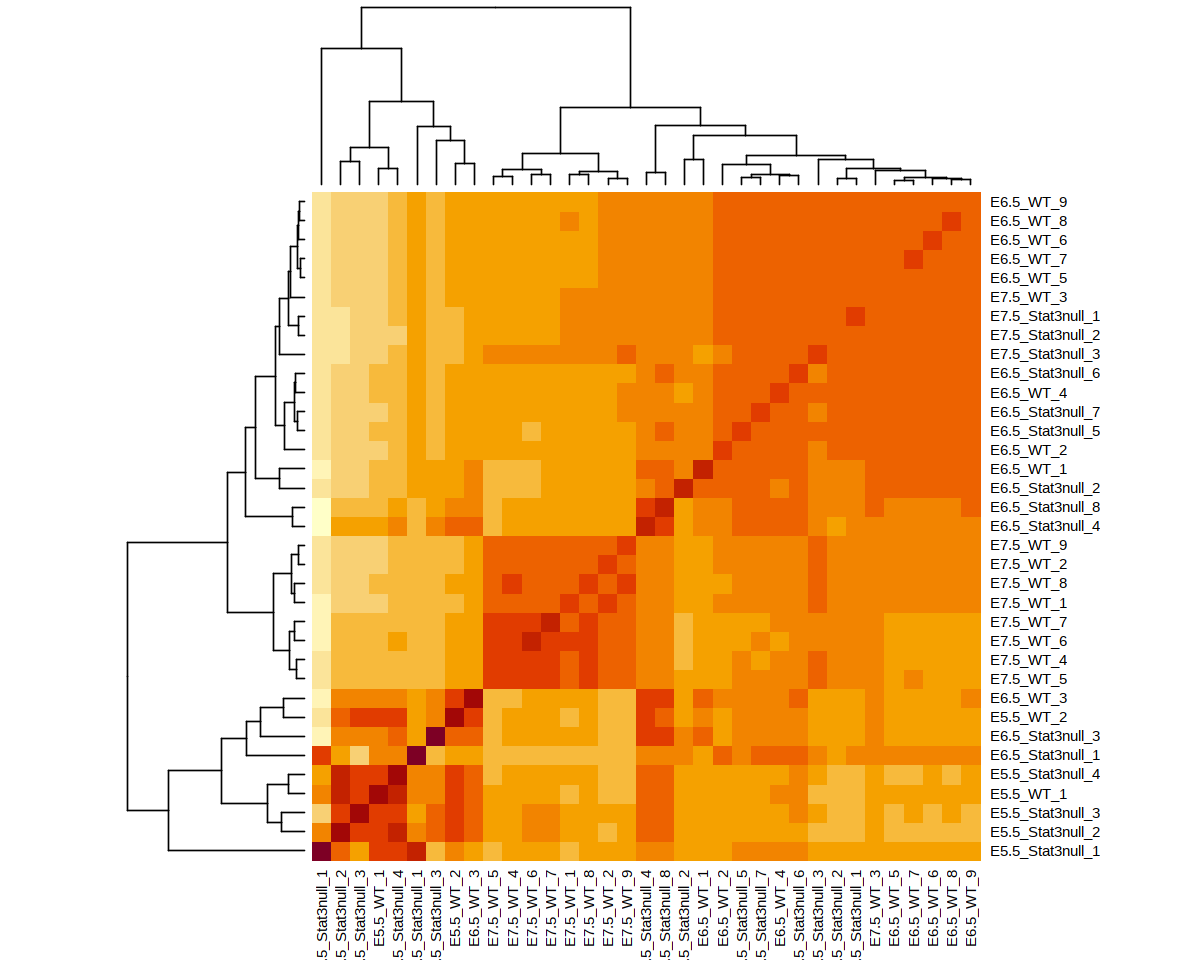

In [491]:
heatmap(test)

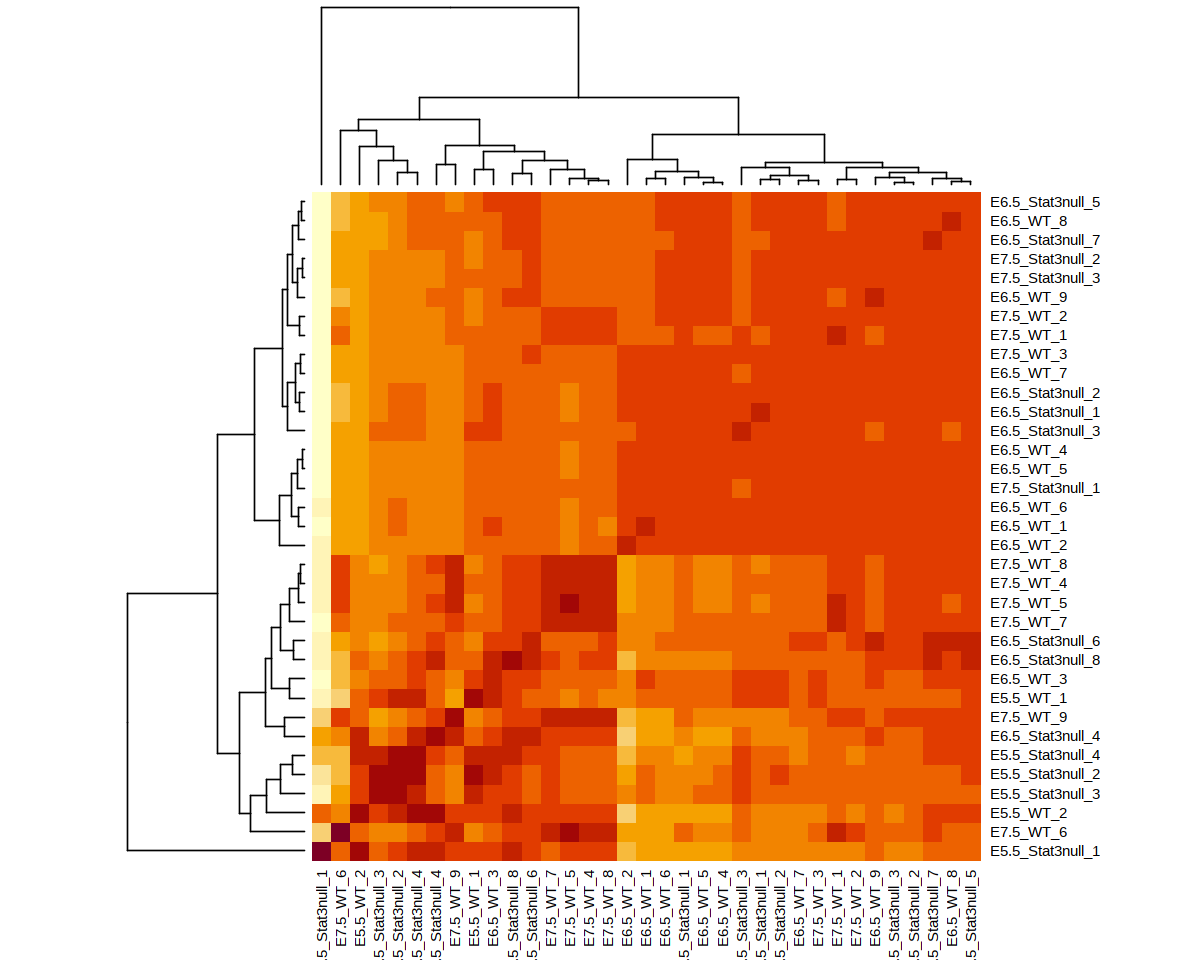

In [489]:
heatmap(test)

In [473]:
gene_pca = pca$rotation
rownames(gene_pca) = var_genes

ERROR: Error in dimnames(x) <- dn: length of 'dimnames' [1] not equal to array extent


In [474]:
PC1 = as.data.table(gene_pca, keep.rownames=T)[,PC1:=abs(PC1)] %>% .[order(-PC1)] %>% head(20) %>% .$rn
PC2 = as.data.table(gene_pca, keep.rownames=T)[,PC2:=abs(PC2)] %>% .[order(-PC2)] %>% head(20) %>% .$rn
label = unique(c(PC1, PC2))

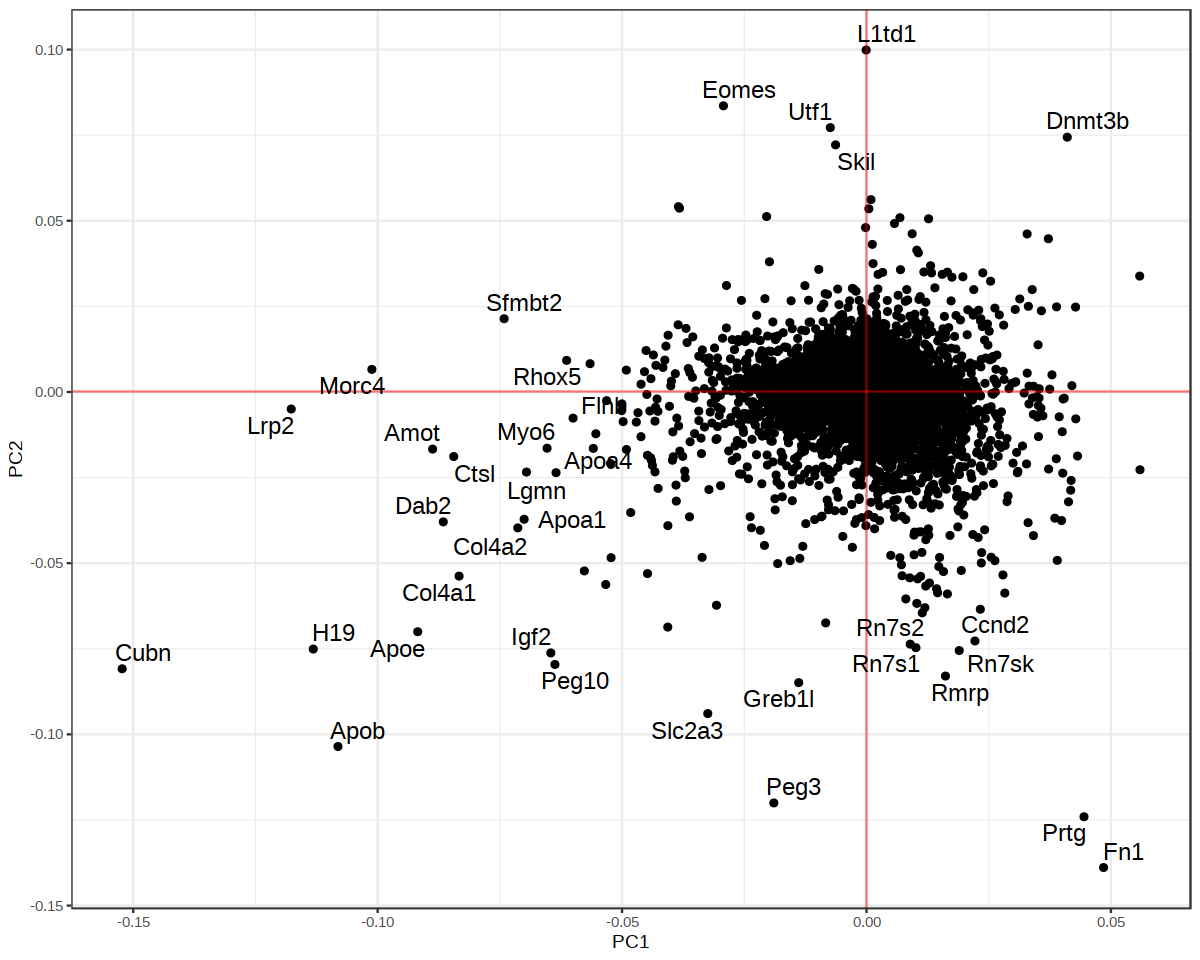

In [462]:
ggplot(as.data.frame(gene_pca), aes(PC1, PC2, label=rownames(gene_pca))) + 
    geom_point() +
    geom_hline(yintercept=0, color='red', alpha=0.5) + geom_vline(xintercept=0, color='red', alpha=0.5)+
    ggrepel::geom_text_repel(data = as.data.frame(gene_pca)[label,], 
             aes(label = label),
             color = "black", size=5) +
    theme_bw() 


In [468]:
test = rlog(test)

rlog() may take a few minutes with 30 or more samples,
vst() is a much faster transformation



ERROR: Error in DESeqDataSet(se, design = design, ignoreRank): some values in assay are not integers


In [467]:
head(test)

,E5.5_Stat3null_1,E5.5_Stat3null_2,E5.5_Stat3null_3,E5.5_Stat3null_4,E5.5_WT_1,E5.5_WT_2,E6.5_Stat3null_1,E6.5_Stat3null_2,E6.5_Stat3null_3,E6.5_Stat3null_4,⋯,E7.5_Stat3null_3,E7.5_WT_1,E7.5_WT_2,E7.5_WT_3,E7.5_WT_4,E7.5_WT_5,E7.5_WT_6,E7.5_WT_7,E7.5_WT_8,E7.5_WT_9
Xkr4,8.661958,8.509491,8.578923,8.475692,8.474776,8.902152,8.723644,9.330489,8.28432,9.097697,⋯,9.394721,9.594842,9.338744,9.207445,9.460465,9.749576,9.194212,9.488223,9.355378,9.473872
Gm18956,8.284320,8.485760,8.284320,8.284320,8.284320,8.284320,8.284320,8.284320,8.28432,8.284320,⋯,8.389282,8.438449,8.284320,8.512559,8.284320,8.284320,8.441732,8.491821,8.284320,8.284320
Gm37686,8.284320,8.284320,8.284320,8.284320,8.284320,8.284320,8.284320,8.284320,8.28432,8.452462,⋯,8.284320,8.744968,8.470449,8.485655,8.444842,8.556354,8.545133,8.284320,8.284320,8.442199
Gm37329,8.284320,8.509491,8.578923,8.633123,8.284320,8.284320,8.284320,8.284320,8.28432,8.284320,⋯,8.518816,8.551026,8.619349,8.615562,8.562066,8.284320,8.660899,8.546655,8.644233,8.284320
Gm38148,8.284320,8.722025,8.709516,8.543282,8.284320,8.521797,8.771983,8.284320,8.28432,8.765314,⋯,8.466040,8.908959,8.917684,8.991650,8.745973,8.845709,8.506824,8.838177,8.953391,9.141615
Gm37180,9.020712,8.458808,8.284320,9.022090,8.284320,8.607636,8.762720,8.610741,8.28432,8.472282,⋯,8.675935,8.843874,8.917684,8.536590,9.239298,8.819270,8.588734,8.591777,8.708058,8.572232
